# 📺 YouTube Streaming Analytics

Análisis comparativo de métricas de engagement para múltiples canales/programas de stream.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime

# 1. Obtener la fecha y hora actual
ahora = datetime.now()
fecha_formateada = ahora.strftime("%Y-%m-%d %H:%M")

# ── Estilo global ──────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#1e1e2e',
    'axes.facecolor': '#2a2a3e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#cdd6f4',
    'xtick.color': '#cdd6f4',
    'ytick.color': '#cdd6f4',
    'text.color': '#cdd6f4',
    'grid.color': '#333355',
    'legend.facecolor': '#2a2a3e',
    'legend.edgecolor': '#444466',
})

PALETTE = sns.color_palette('husl', 10)

# ── Cargar datos ───────────────────────────────────────────────────────────
DATA_PATH = Path('../data/raw/latest.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'No se encontró {DATA_PATH}.\n'
        'Primero corré: python main.py'
    )

df = pd.read_csv(DATA_PATH, parse_dates=['published_at'])
df['published_date'] = pd.to_datetime(df['published_date'])

print(f"*** Reporte basado en la consulta hecha el {fecha_formateada} ***")
print(f'✓ Datos cargados: {len(df)} videos de {df["playlist_name"].nunique()} playlists')
print(f'  Período: {df["published_date"].min().date()} → {df["published_date"].max().date()}')
df.head(3)

*** Reporte basado en la consulta hecha el 2026-06-25 22:40 ***
✓ Datos cargados: 485 videos de 6 playlists
  Período: 2025-11-04 → 2026-06-25


,video_id,title,channel_title,published_at,duration,duration_seconds,views,likes,comments,comments_disabled,playlist_name,playlist_id,like_rate,comment_rate,engagement_rate,published_date
0,9J3w6BFPIVA,QUILOMBO EN DIPUTADOS Y JUEVES DE FILMINAS | #...,Vorterix,2026-06-25 17:52:04+00:00,PT2H44M15S,9855,36794,4450,84,False,Vorterix — Y Qué?,PLHZOhV2rP0rkZ6VS01vvddeHrr7220LcM,0.120944,0.002283,0.123227,2026-06-25
1,nsCKVWNvlyo,EL SUPERFESTEJO DEL CUMPLE DE ANACLETA | #YQUE...,Vorterix,2026-06-24 17:57:59+00:00,PT2H44M18S,9858,80198,8023,327,False,Vorterix — Y Qué?,PLHZOhV2rP0rkZ6VS01vvddeHrr7220LcM,0.100040,0.004077,0.104117,2026-06-24
2,oshTaQM0XTw,NAVAJA NOS FUE INFIEL CON LULI OFMAN y NOTIFED...,Vorterix,2026-06-23 18:03:52+00:00,PT2H46M12S,9972,74313,6030,217,False,Vorterix — Y Qué?,PLHZOhV2rP0rkZ6VS01vvddeHrr7220LcM,0.081143,0.002920,0.084063,2026-06-23


---
## 1. Tabla comparativa por playlist

Mediana de views, likes y ratios de engagement para cada programa.

In [22]:
import sys
sys.path.insert(0, '..')
from src.metrics import aggregate_by_playlist

df_agg = aggregate_by_playlist(df)

# Formatear para mostrar
display_cols = [
    'playlist_name', 'video_count',
    'median_views', 'median_likes',
    'median_like_rate', 'median_engagement_rate',
    'p25_engagement_rate', 'p75_engagement_rate',
    'top_video_title'
]

df_display = df_agg[display_cols].copy()
df_display['median_views'] = df_display['median_views'].map('{:,.0f}'.format)
df_display['median_likes'] = df_display['median_likes'].map('{:,.0f}'.format)
df_display['median_like_rate'] = df_display['median_like_rate'].map('{:.4f}'.format)
df_display['median_engagement_rate'] = df_display['median_engagement_rate'].map('{:.4f}'.format)
df_display['p25_engagement_rate'] = df_display['p25_engagement_rate'].map('{:.4f}'.format)
df_display['p75_engagement_rate'] = df_display['p75_engagement_rate'].map('{:.4f}'.format)

df_display.style.set_caption('Métricas agregadas por playlist (ordenadas por engagement_rate mediana ↓)')

,playlist_name,video_count,median_views,median_likes,median_like_rate,median_engagement_rate,p25_engagement_rate,p75_engagement_rate,top_video_title
5,Vorterix — Y Qué?,80,"58,356","4,408",0.0715,0.0742,0.0677,0.0843,QUILOMBO EN DIPUTADOS Y JUEVES DE FILMINAS | #YQUE COMPLETO 25/6 | VORTERIX
2,Olga - Sería Increíble,100,"212,512","6,584",0.0314,0.0324,0.0300,0.0340,¡10 AÑOS DESPUÉS! Vero LOZANO y Leo MONTERO VUELVEN en #SeríaIncreíble 22/6
3,Olga — Soñe Que Volaba,100,"181,952","5,793",0.0298,0.0304,0.0279,0.0346,MIGUE y HOMERO GUARDAN su SECRETO en la LUNA | #SoñéQueVolaba 6/4
4,Vorterix - Paren La Mano,78,"281,636","7,891",0.0285,0.0297,0.0268,0.0329,VIERNES DE BLACKJACK CON DIEGO DIAZ | #ParenLaMano Completo - 13/03 | VORTERIX
1,Luzu - Nadie Dice Nada,100,"1,191,930","33,250",0.0279,0.0286,0.0270,0.0313,"#NADIEDICENADA | UN NUEVO MOMI A CIEGAS, CONOCEMOS A CARLOS SOÚL Y ¿SANTI NO PONE LÍMITES?"
0,Blender - Hay Algo Ahí,27,"103,738","2,510",0.0264,0.0271,0.0215,0.0325,HISTÓRICA SALA DE SITUABORD con MILEI DESATADO en TODOS LOS AUDIOS FILTRADOS | HAY ALGO AHÍ


---
## 2. Distribución de Like Rate por playlist

Boxplot que muestra la mediana, dispersión e outliers de cada programa.

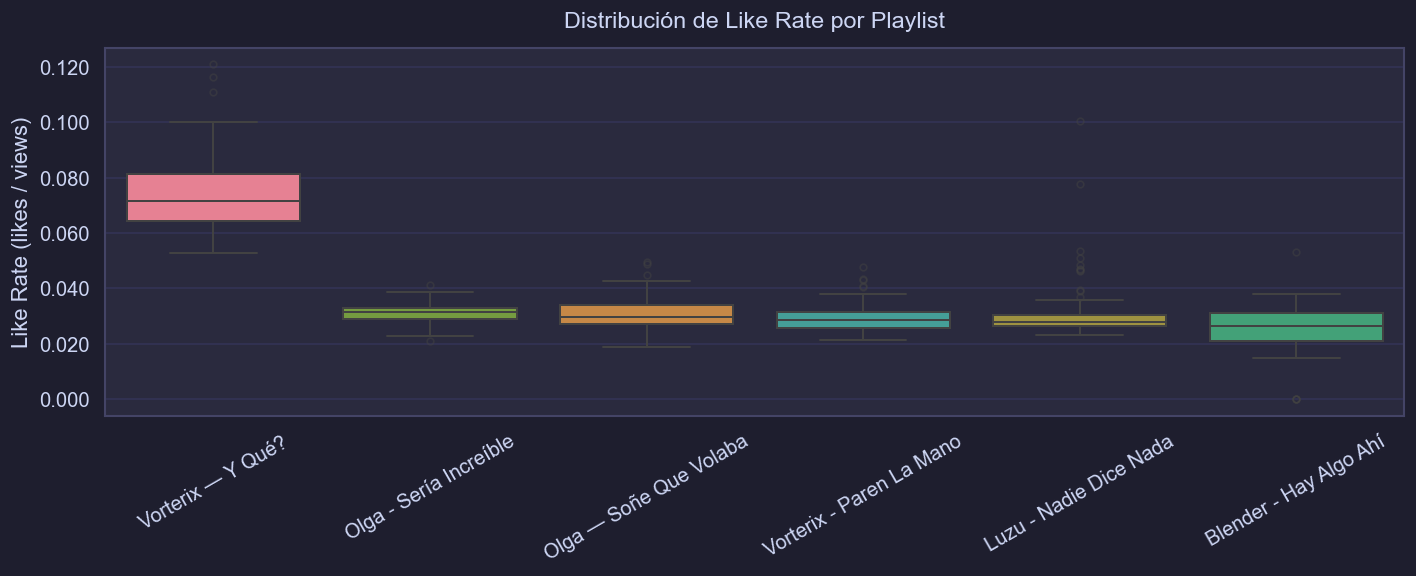

In [23]:
playlist_order = df_agg['playlist_name'].tolist()  # orden por engagement rate

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=df,
    x='playlist_name',
    y='like_rate',
    hue='playlist_name',      # 👈 1. Asignamos la misma variable a hue para mantener los colores
    legend=False,             # 👈 2. Ocultamos la leyenda automática que genera hue
    order=playlist_order,
    palette=PALETTE[:len(playlist_order)], # 👈 3. Recortamos la paleta para que tenga los mismos colores que playlists
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    ax=ax,
)

ax.set_title('Distribución de Like Rate por Playlist', fontsize=14, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Like Rate (likes / views)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

---
## 3. Comparativa directa de medianas — Barras

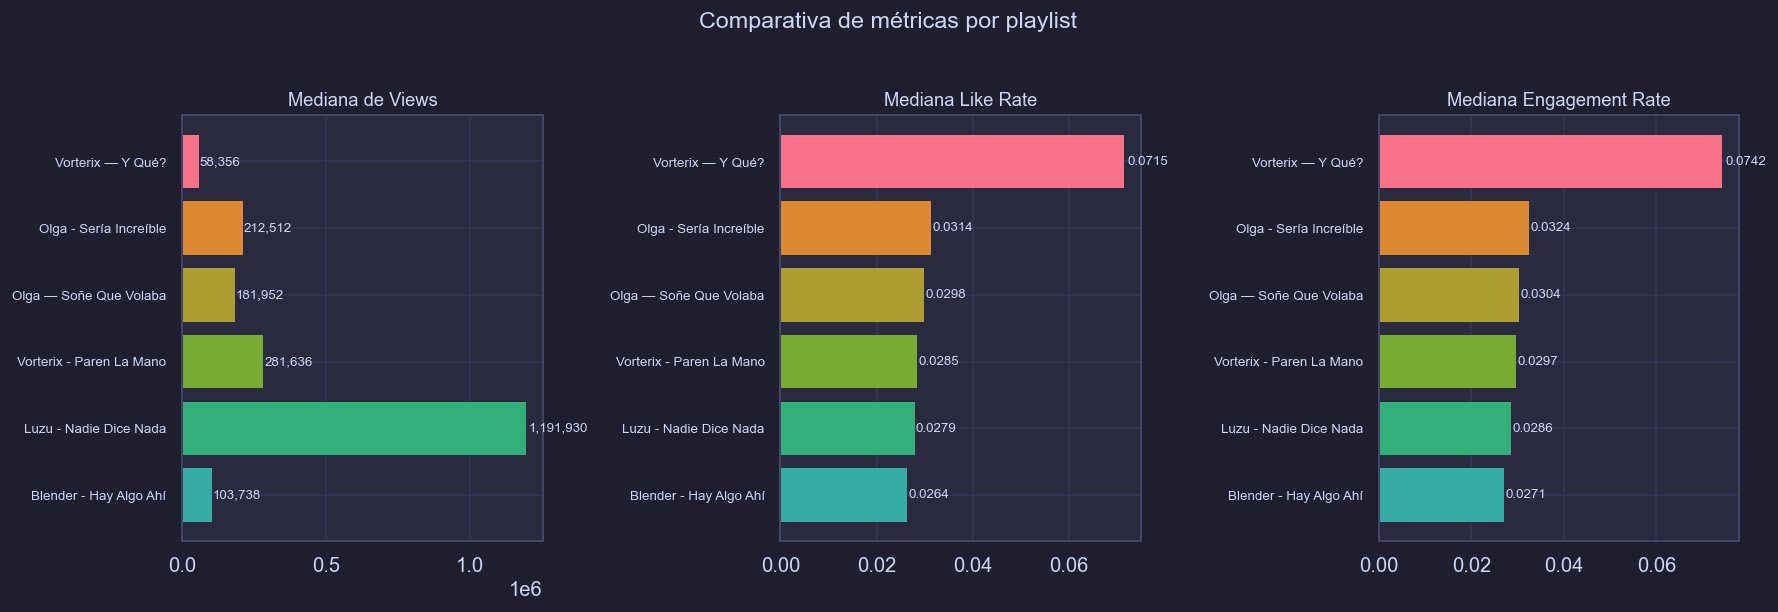

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = [
    ('median_views', 'Mediana de Views', '{:,.0f}'),
    ('median_like_rate', 'Mediana Like Rate', '{:.4f}'),
    ('median_engagement_rate', 'Mediana Engagement Rate', '{:.4f}'),
]

for ax, (col, title, fmt) in zip(axes, metrics_to_plot):
    bars = ax.barh(
        df_agg['playlist_name'],
        df_agg[col],
        color=PALETTE[:len(df_agg)],
        edgecolor='none',
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

    for bar, val in zip(bars, df_agg[col]):
        ax.text(
            bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            fmt.format(val), va='center', fontsize=8,
            color='#cdd6f4'
        )

fig.suptitle('Comparativa de métricas por playlist', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 4. Evolución temporal — Like Rate a lo largo del tiempo

Muestra cómo evoluciona el engagement de cada programa según la fecha de publicación.

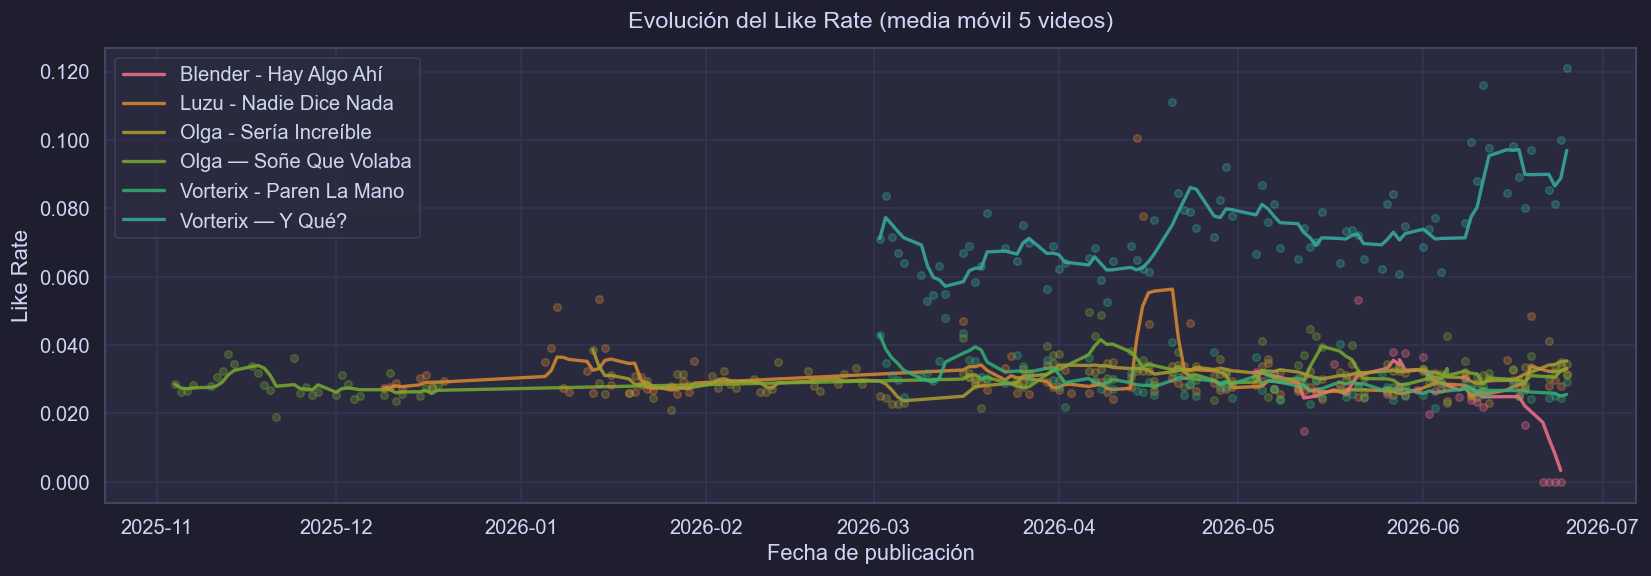

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))

for i, (playlist_name, group) in enumerate(df.groupby('playlist_name')):
    group_sorted = group.sort_values('published_date')
    # Media móvil de 5 videos para suavizar la curva
    group_sorted['like_rate_smooth'] = group_sorted['like_rate'].rolling(5, min_periods=1).mean()

    ax.plot(
        group_sorted['published_date'],
        group_sorted['like_rate_smooth'],
        label=playlist_name,
        color=PALETTE[i % len(PALETTE)],
        linewidth=2,
        alpha=0.85,
    )
    # Puntos individuales con baja opacidad
    ax.scatter(
        group_sorted['published_date'],
        group_sorted['like_rate'],
        color=PALETTE[i % len(PALETTE)],
        s=20, alpha=0.3, zorder=3,
    )

ax.set_title('Evolución del Like Rate (media móvil 5 videos)', fontsize=14, pad=12)
ax.set_xlabel('Fecha de publicación')
ax.set_ylabel('Like Rate')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.legend(loc='upper left', framealpha=0.7)
fig.tight_layout()
plt.show()

---
## 5. Top 10 videos por engagement rate (global)

In [26]:
top10 = df.nlargest(10, 'engagement_rate')[[
    'playlist_name', 'title', 'published_date',
    'views', 'likes', 'comments',
    'like_rate', 'engagement_rate'
]].reset_index(drop=True)

top10.index += 1  # rank desde 1

top10_display = top10.copy()
top10_display['views'] = top10_display['views'].map('{:,.0f}'.format)
top10_display['likes'] = top10_display['likes'].map('{:,.0f}'.format)
top10_display['like_rate'] = top10_display['like_rate'].map('{:.4f}'.format)
top10_display['engagement_rate'] = top10_display['engagement_rate'].map('{:.4f}'.format)

top10_display.style\
    .set_caption('🏆 Top 10 videos por engagement rate')\
    .background_gradient(subset=['engagement_rate'], cmap='YlOrRd')

,playlist_name,title,published_date,views,likes,comments,like_rate,engagement_rate
1,Vorterix — Y Qué?,QUILOMBO EN DIPUTADOS Y JUEVES DE FILMINAS | #YQUE COMPLETO 25/6 | VORTERIX,2026-06-25 00:00:00,"36,794","4,450",84,0.1209,0.1232
2,Vorterix — Y Qué?,EMPATÍA CON ADORNI Y SUS BITCOIN CARAY | #YQUE COMPLETO 11/6 | VORTERIX,2026-06-11 00:00:00,"54,141","6,291",123,0.1162,0.1185
3,Vorterix — Y Qué?,"LA RAVE RELIGIOSA, NOTIFEDERAL Y GUILLE PRÓCER | #YQUE COMPLETO 20/04 | VORTERIX",2026-04-20 00:00:00,"55,862","6,202",394,0.1110,0.1181
4,Vorterix — Y Qué?,EL SUPERFESTEJO DEL CUMPLE DE ANACLETA | #YQUE COMPLETO 24/6 | VORTERIX,2026-06-24 00:00:00,"80,198","8,023",327,0.1000,0.1041
5,Vorterix — Y Qué?,RELACIONES ENTRE PRIMOS CON FEDE SIMONETTI | #YQUE COMPLETO 9/6 | VORTERIX,2026-06-09 00:00:00,"64,208","6,373",275,0.0993,0.1035
6,Vorterix — Y Qué?,FLOR PEÑA NOS OBLIGÓ A QUE VUELVA EL TOP FIVE | #YQUE COMPLETO 19/06 | VORTERIX,2026-06-19 00:00:00,"84,292","8,192",397,0.0972,0.1019
7,Luzu - Nadie Dice Nada,"#NADIEDICENADA | UN NUEVO MOMI A CIEGAS, CONOCEMOS A CARLOS SOÚL Y ¿SANTI NO PONE LÍMITES?",2026-04-14 00:00:00,"1,142,088","114,903",1454,0.1006,0.1019
8,Vorterix — Y Qué?,FIEBRE MUNDIALISTA Y EL GRAN JUEGO DE TROLLÍN | #YQUE COMPLETO 16/6 | VORTERIX,2026-06-16 00:00:00,"55,479","5,444",138,0.0981,0.1006
9,Vorterix — Y Qué?,VINO JULIETA PINK Y DESAPARECIÓ TROLLÍN... | #YQUE COMPLETO 12/6 | VORTERIX,2026-06-12 00:00:00,"60,043","5,863",143,0.0976,0.1000
10,Vorterix — Y Qué?,SE VIENE EL APOCALIPSIS Y CONOCIMOS NOVIOS CURIOSOS | #YQUE COMPLETO 29/04 | VORTERIX,2026-04-29 00:00:00,"57,780","5,317",175,0.0920,0.0951


---
## 6. Scatter: Views vs Like Rate por playlist

¿Los videos más vistos tienen mejor o peor engagement?

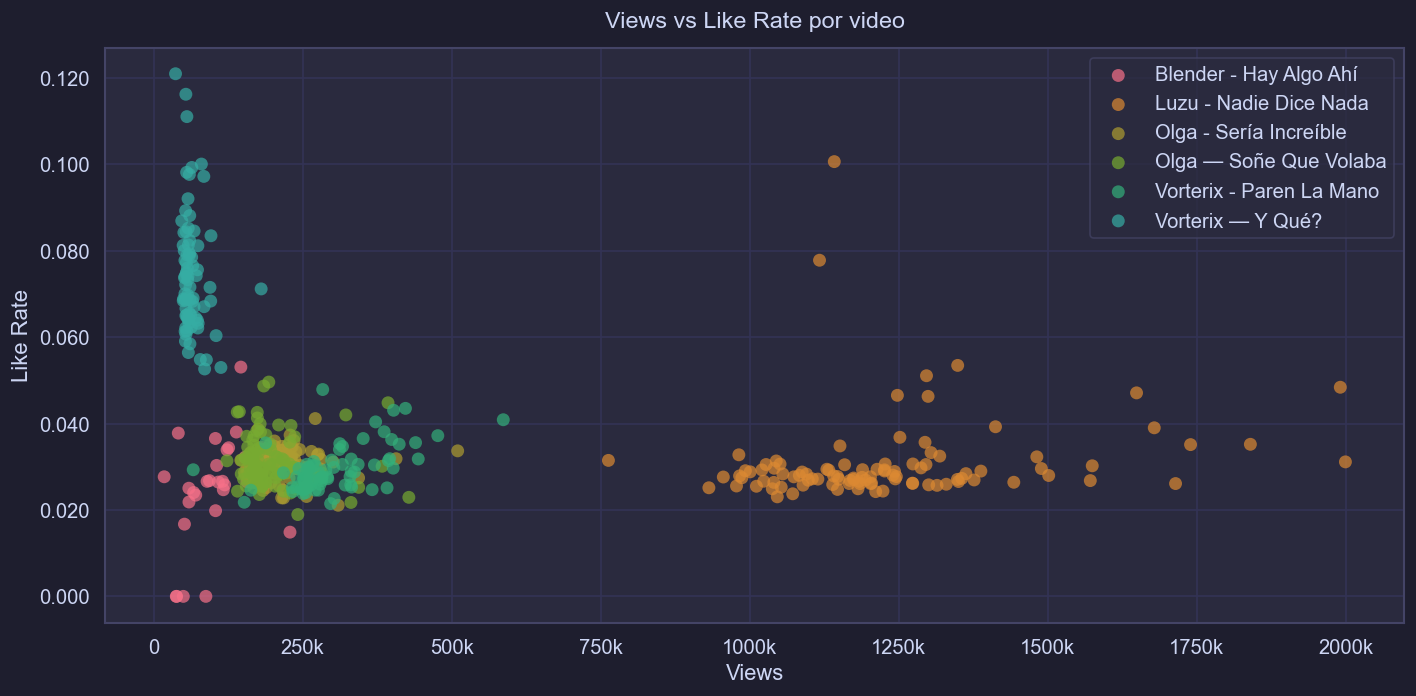

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, (playlist_name, group) in enumerate(df.groupby('playlist_name')):
    ax.scatter(
        group['views'],
        group['like_rate'],
        label=playlist_name,
        color=PALETTE[i % len(PALETTE)],
        s=60, alpha=0.7, edgecolors='none',
    )

ax.set_title('Views vs Like Rate por video', fontsize=14, pad=12)
ax.set_xlabel('Views')
ax.set_ylabel('Like Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.legend(loc='upper right', framealpha=0.7)
fig.tight_layout()
plt.show()

---
## 7. Último episodio de cada playlist — Like Rate comparativo

Comparación del like_rate del **episodio más reciente** disponible de cada programa.
La línea punteada muestra la mediana global como referencia.

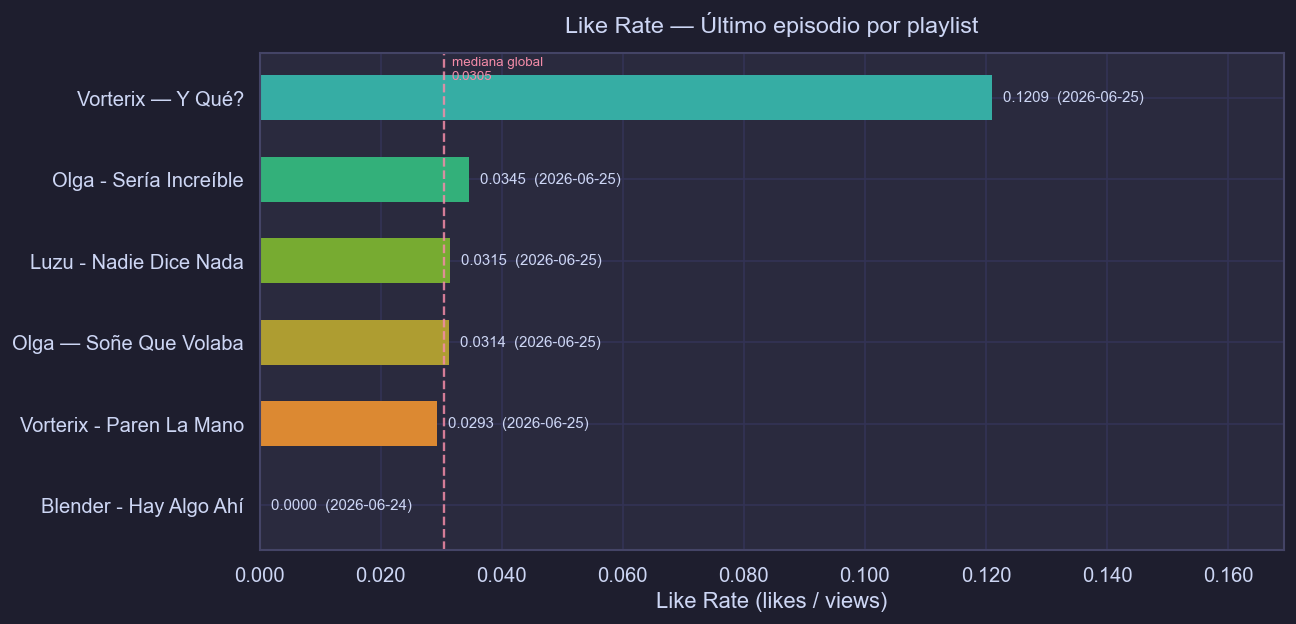


Resumen — último episodio por playlist:


,playlist_name,title,published_date,views,likes,like_rate
1,Vorterix — Y Qué?,QUILOMBO EN DIPUTADOS Y JUEVES DE FILMINAS | #...,2026-06-25,"36,794","4,450",0.1209
2,Olga - Sería Increíble,VERO y LEO se VUELVEN a VER con BARASSI y LUSS...,2026-06-25,"230,084","7,946",0.0345
3,Luzu - Nadie Dice Nada,#NADIEDICENADA l EL PSICÓLOGO DE MARTIN JUEGA ...,2026-06-25,"763,143","24,013",0.0315
4,Olga — Soñe Que Volaba,SINCERIDAD SIN EMPATÍA ES CRUELDAD (estaban re...,2026-06-25,"123,095","3,862",0.0314
5,Vorterix - Paren La Mano,UTOPIAS IMPOSIBLES Y EL CONSULTORIO DE EDUL | ...,2026-06-25,"66,485","1,948",0.0293
6,Blender - Hay Algo Ahí,MIÉRCOLES de PUCHOS HISTÓRICO sobre COMEPECADO...,2026-06-24,"49,868",0,0.0000


In [28]:
# Obtener el video más reciente (mayor published_date) de cada playlist
df_latest = (
    df.sort_values('published_date', ascending=False)
    .groupby('playlist_name', sort=False)
    .first()
    .reset_index()
)

# Ordenar de menor a mayor para que el mayor quede arriba en el gráfico horizontal
df_latest = df_latest.sort_values('like_rate', ascending=True)

fig, ax = plt.subplots(figsize=(11, max(4, len(df_latest) * 0.9)))

colors = [PALETTE[i % len(PALETTE)] for i in range(len(df_latest))]
bars = ax.barh(
    df_latest['playlist_name'],
    df_latest['like_rate'],
    color=colors,
    edgecolor='none',
    height=0.55,
)

# Etiqueta: like_rate + fecha de publicación del episodio
x_max = df_latest['like_rate'].max()
for bar, (_, row) in zip(bars, df_latest.iterrows()):
    fecha = str(row['published_date'])[:10]
    label = f"{row['like_rate']:.4f}  ({fecha})"
    ax.text(
        bar.get_width() + x_max * 0.015,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', fontsize=9, color='#cdd6f4',
    )

# Línea de mediana global como referencia
global_median = df['like_rate'].median()
ax.axvline(global_median, color='#f38ba8', linewidth=1.4, linestyle='--', alpha=0.85)
ax.text(
    global_median + x_max * 0.01,
    len(df_latest) - 0.5,
    f'mediana global\n{global_median:.4f}',
    color='#f38ba8', fontsize=8, va='top',
)

ax.set_title('Like Rate — Último episodio por playlist', fontsize=14, pad=12)
ax.set_xlabel('Like Rate (likes / views)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.set_xlim(0, x_max * 1.40)  # margen derecho para las etiquetas
fig.tight_layout()
plt.show()

# Tabla resumen debajo del gráfico
print('\nResumen — último episodio por playlist:')
summary = df_latest[['playlist_name', 'title', 'published_date', 'views', 'likes', 'like_rate']].copy()
summary['views'] = summary['views'].map('{:,.0f}'.format)
summary['likes'] = summary['likes'].map('{:,.0f}'.format)
summary['like_rate'] = summary['like_rate'].map('{:.4f}'.format)
summary = summary.sort_values('like_rate', ascending=False).reset_index(drop=True)
summary.index += 1
display(summary)